# Practical 5 — Tree-Based Machine Learning for QSAR

**Machine Learning for Bioinformatics**

**Dataset:** chembl_cytotoxicity_rdkit_descriptors_outcomes.csv  
**Main task:** predict the continuous pchembl_value target from RDKit molecular descriptors.

This practical follows one dataset from data preparation to model comparison:

1. inspect the assay table and apply the universal data-preparation checklist;
2. resolve repeated measurements at the molecule level;
3. fit and visualize a single decision tree;
4. study complexity, overfitting, and pruning;
5. compare bagging, Random Forest, and Gradient Boosting;
6. inspect descriptor importance and applicability-domain outliers;
7. use cross-validation and hyperparameter search;
8. optionally compare external boosting libraries and build a stacking ensemble.

The dataset is intentionally biologically messy: the same molecule may have several assay outcomes, and the table combines IC50 and EC50 measurements. Treat the result as a teaching QSAR exercise, not as a validated pharmacological model.


## Learning objectives

By the end of the practical, you should be able to:

- explain what a QSAR table represents and identify its observational unit;
- distinguish molecule descriptors from identifiers, assay metadata, and outcomes;
- detect repeated molecules, missing descriptor values, and possible leakage;
- explain why a single decision tree can overfit;
- compare variance reduction by bagging and Random Forest with sequential correction by boosting;
- tune tree depth, leaf size, number of trees, and learning rate;
- use permutation importance without describing it as causal evidence;
- choose a cross-validation design that matches the biological generalization question;
- explain why out-of-fold predictions are needed for stacking.


## 0. Setup

The practical uses numpy, pandas, matplotlib, and scikit-learn. XGBoost, LightGBM, and Optuna are part of the course environment. Plotly is used for interactive figures that can be zoomed and opened in a separate output view.

Plots use the interactive Matplotlib widget backend when ipympl is available. This adds a toolbar for zooming and panning; in JupyterLab, use the output menu to create a separate view for a figure. If the widget backend is unavailable, the notebook falls back to static inline figures.

The target is a regression outcome, so the main evaluation metrics are RMSE, MAE, and \(R^2\). The final test set is used only after model choices have been made with the training data and cross-validation.


In [1]:
import time
import pubchempy as pcp
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import (
    BaggingRegressor,
    GradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree

RANDOM_STATE = 100626

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def show_metrics(name, y_true, y_pred):
    values = regression_metrics(y_true, y_pred)
    print(name)
    print(f"  RMSE: {values['RMSE']:.3f}")
    print(f"  MAE:  {values['MAE']:.3f}")
    print(f"  R²:   {values['R2']:.3f}")
    return values


# Part I — Dataset and data preparation

## 1. What is measured?

The file is an assay-level table extracted from ChEMBL:

- each raw row is one reported activity measurement for a molecule in an assay;
- molecule_chembl_id identifies the chemical structure;
- canonical_smiles is a machine-readable molecular representation;
- standard_type contains the endpoint label, IC50 or EC50 here;
- standard_value and standard_units contain the standardized potency measurement;
- pchembl_value is the modelling target, approximately \(-\log_{10}\) of molar potency, so larger values usually indicate stronger potency;
- columns beginning with rdkit_ are numerical molecular descriptors calculated from the structure.

The table mixes assay contexts and endpoint types. Therefore, the target is useful for demonstrating a workflow, but it should not be interpreted as one perfectly homogeneous biological endpoint.


In [2]:
df_raw = pd.read_csv('chembl_cytotoxicity_rdkit_descriptors_outcomes_with_pubchem_names.csv')

df_raw.head(3)



,molecule_chembl_id,canonical_smiles,standard_type,test_type,standard_units,unit,standard_value,value,pchembl_value,assay_chembl_id,...,rdkit_fr_term_acetylene,rdkit_fr_tetrazole,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea,pubchem_cid,pubchem_iupac_name,pubchem_status
0,CHEMBL300734,COc1ccc2c(c1)C=CCc1cc(OC)c(OC)c(OC)c1-2,IC50,IC50,nM,nM,60.0,60.0,7.22,CHEMBL615179,...,0,0,0,0,0,0,0,628524.0,"5,13,14,15-tetramethoxytricyclo[9.4.0.02,7]pen...",matched
1,CHEMBL329817,COc1ccc2c(c1)[C@@H](NC(=O)CCl)CCc1cc(OC)c(OC)c...,IC50,IC50,nM,nM,2.7,2.7,8.57,CHEMBL615179,...,0,0,0,0,0,0,0,10386594.0,"2-chloro-N-[(8S)-5,13,14,15-tetramethoxy-8-tri...",matched
2,CHEMBL107,COc1cc2c(c(OC)c1OC)-c1ccc(OC)c(=O)cc1[C@@H](NC...,IC50,IC50,nM,nM,11.9,11.9,7.92,CHEMBL615179,...,0,0,0,0,0,0,0,6167.0,"N-[(7S)-1,2,3,10-tetramethoxy-9-oxo-6,7-dihydr...",matched


## 2. Universal data-preparation checklist



### Scientific purpose and provenance

- [ ] Is the biological question and prediction task clear?
- [ ] Is the unit of observation clear?
- [ ] Do I know where the data came from and how it was generated?
- [ ] Are the data version, processing history, and transformations recorded?



### Table shape and identifiers

- [ ] Is the table tidy: one observation per row and one variable per column?
- [ ] Are row names, column names, and identifiers clear and unique?
- [ ] Can every feature and observation be traced to its source?
- [ ] Are features and metadata aligned by an explicit identifier?

### Types, values, and measurement meaning

- [ ] Are numerical, categorical, text, and identifier columns correctly classified?
- [ ] Are units, scales, encodings, and detection limits understood?
- [ ] Have impossible values, inconsistent labels, constant descriptors, and extreme values been checked?
- [ ] Are transformations and normalization steps documented?


In [3]:

check_descriptor_cols = [c for c in df_raw.columns if c.startswith("rdkit_")]
df_raw.select_dtypes(include=np.number).columns.tolist()
df_raw.select_dtypes(exclude=np.number).columns.tolist()
np.isinf(df_raw[check_descriptor_cols]).sum().sort_values(ascending=False)
df_raw.columns[df_raw.columns.duplicated()].tolist()
df_raw["standard_units"].value_counts().to_dict(),




({'nM': 12306},)


### Missing values

- [ ] Have missing values been detected using the dataset's actual representations?
- [ ] Has missingness been measured by row, column, and relevant group?
- [ ] Is missingness structural, technical, or plausibly biological?
- [ ] Is retain/remove/impute justified?
- [ ] If imputing, is the imputer fitted on training data only?

### Replicates, dependence, and grouping

- [ ] Have exact duplicates and repeated measurements been checked?
- [ ] Are observations biological replicates, technical replicates, or repeated assays?
- [ ] Is the independent biological or chemical unit identified?
- [ ] Will related observations remain in the same split?
- [ ] Is any synthetic or augmented data provenance recorded?


In [4]:
df_raw.isna().sum()
df_raw.groupby("standard_type").agg(raw_rows=("molecule_chembl_id", "size"),
        unique_molecules=("molecule_chembl_id", "nunique"),
        molecules_with_repeats=(
            "molecule_chembl_id",
            lambda s: int((s.value_counts() > 1).sum()),
        ),
        maximum_measurements_per_molecule=("molecule_chembl_id", lambda s: int(s.value_counts().max())),
    ).sort_values("raw_rows", ascending=False)
df_raw.duplicated().sum()
df_raw["molecule_chembl_id"].duplicated().sum()
df_raw["assay_chembl_id"].nunique()
df_raw["standard_type"].nunique()



2


### Target, leakage, and study design

- [ ] Is the target defined and its range checked?
- [ ] Have identifiers and duplicated target information been excluded from features?
- [ ] Have assay, cell line, batch, site, treatment, and cohort effects been considered?
- [ ] Is the target associated with a technical or grouping variable?
- [ ] Does the split represent the desired biological generalization question?

### Reproducibility and decision record

- [ ] Are seeds, software versions, file names, and shapes recorded?
- [ ] Are preprocessing steps in a reproducible pipeline?
- [ ] Are unresolved concerns and decisions written down?
- [ ] Can another person explain every row, column, feature, target, and grouping variable?


In [5]:
TARGET = "pchembl_value"
MOLECULE_ID = "molecule_chembl_id"
SMILES_COLUMN = "canonical_smiles"
descriptor_cols = [c for c in df_raw.columns if c.startswith("rdkit_")]

metadata_cols = [
    "standard_type", "test_type", "standard_units", "unit",
    "assay_chembl_id", "assay_type", "bao_format"]


print("Endpoint values:", df_raw["standard_type"].value_counts().to_dict())
print("Units:", df_raw["standard_units"].value_counts().to_dict())
print("Unique molecules:", df_raw[MOLECULE_ID].nunique())
print("Repeated raw rows:", df_raw.duplicated().sum())


Endpoint values: {'IC50': 10996, 'EC50': 1310}
Units: {'nM': 12306}
Unique molecules: 6141
Repeated raw rows: 11


## 3. Initial diagnostics

Before modelling, inspect the target, missingness, duplicate rows, repeated molecules, and descriptor variability. A repeated molecule is not automatically an error: it may represent independent assay measurements. It becomes a leakage problem when measurements of the same molecule are split across train and test without a deliberate grouping strategy.


In [6]:
target_distribution_fig = px.histogram(
    df_raw, x=TARGET, nbins=35, color="standard_type",
    marginal="box", title="Raw assay target distribution by endpoint",
    labels={TARGET: "pChEMBL value", "count": "Raw assay rows"},
)
target_distribution_fig.update_layout(barmode="overlay")
target_distribution_fig.update_traces(opacity=0.70)
target_distribution_fig.show()

endpoint_counts = df_raw["standard_type"].value_counts().rename_axis("endpoint").reset_index(name="rows")
endpoint_fig = px.bar(
    endpoint_counts, x="endpoint", y="rows", color="endpoint",
    title="Number of raw assay rows per endpoint",
)
endpoint_fig.show()


## 4. Select one endpoint and one row per molecule

The raw table contains two endpoint types. We select the endpoint with the largest number of raw observations. In this dataset that is expected to be IC50.

Within the selected endpoint, some molecules still have repeated assay measurements. We do **not** average them. Instead, we sort by molecule ID and assay ID using a stable sort, then retain the first row for each molecule. If exact ties remain, the original file order is preserved. This gives exactly one observed endpoint measurement per molecule without using the target to choose the row.


In [7]:
endpoint_counts = df_raw["standard_type"].value_counts()
selected_endpoint = endpoint_counts.index[0]
endpoint_df = df_raw.loc[df_raw["standard_type"] == selected_endpoint].copy()

endpoint_measurement_counts = endpoint_df[MOLECULE_ID].value_counts()
endpoint_df["n_endpoint_measurements"] = endpoint_df[MOLECULE_ID].map(endpoint_measurement_counts).astype(int)
endpoint_df

,molecule_chembl_id,canonical_smiles,standard_type,test_type,standard_units,unit,standard_value,value,pchembl_value,assay_chembl_id,...,rdkit_fr_tetrazole,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea,pubchem_cid,pubchem_iupac_name,pubchem_status,n_endpoint_measurements
0,CHEMBL300734,COc1ccc2c(c1)C=CCc1cc(OC)c(OC)c(OC)c1-2,IC50,IC50,nM,nM,60.0,60.0,7.22,CHEMBL615179,...,0,0,0,0,0,0,628524.0,"5,13,14,15-tetramethoxytricyclo[9.4.0.02,7]pen...",matched,2
1,CHEMBL329817,COc1ccc2c(c1)[C@@H](NC(=O)CCl)CCc1cc(OC)c(OC)c...,IC50,IC50,nM,nM,2.7,2.7,8.57,CHEMBL615179,...,0,0,0,0,0,0,10386594.0,"2-chloro-N-[(8S)-5,13,14,15-tetramethoxy-8-tri...",matched,2
2,CHEMBL107,COc1cc2c(c(OC)c1OC)-c1ccc(OC)c(=O)cc1[C@@H](NC...,IC50,IC50,nM,nM,11.9,11.9,7.92,CHEMBL615179,...,0,0,0,0,0,0,6167.0,"N-[(7S)-1,2,3,10-tetramethoxy-9-oxo-6,7-dihydr...",matched,7
3,CHEMBL95224,COc1ccc2c(c1)[C@@H]1O[C@@H]1Cc1cc(OC)c(OC)c(OC...,IC50,IC50,nM,nM,82.0,82.0,7.09,CHEMBL615179,...,0,0,0,0,0,0,9973774.0,"(2S,4R)-8,9,10,15-tetramethoxy-3-oxatetracyclo...",matched,1
4,CHEMBL1280,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,IC50,IC50,nM,nM,58000.0,58000.0,4.24,CHEMBL615298,...,0,0,0,0,0,0,62969.0,"2-(3,4-dimethoxyphenyl)-5-[2-(3,4-dimethoxyphe...",matched,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12301,CHEMBL5074478,CC1=C(C#N)c2nc(N)c(C#N)c(C)c2/C1=C\c1ccc(-c2cc...,IC50,IC50,nM,nM,2430.0,2430.0,5.61,CHEMBL5714923,...,0,0,0,0,0,0,1775581.0,"3-[5-[(Z)-(2-amino-3,7-dicyano-4,6-dimethylcyc...",matched,3
12302,CHEMBL5074478,CC1=C(C#N)c2nc(N)c(C#N)c(C)c2/C1=C\c1ccc(-c2cc...,IC50,IC50,nM,nM,2060.0,2060.0,5.69,CHEMBL5714924,...,0,0,0,0,0,0,1775581.0,"3-[5-[(Z)-(2-amino-3,7-dicyano-4,6-dimethylcyc...",matched,3
12303,CHEMBL5074478,CC1=C(C#N)c2nc(N)c(C#N)c(C)c2/C1=C\c1ccc(-c2cc...,IC50,IC50,nM,nM,1050.0,1050.0,5.98,CHEMBL5714925,...,0,0,0,0,0,0,1775581.0,"3-[5-[(Z)-(2-amino-3,7-dicyano-4,6-dimethylcyc...",matched,3
12304,CHEMBL382362,CC(=O)N1CCN(C(=O)c2cc(CSc3cnc(NC(=O)c4ccc(CNC(...,IC50,IC50,nM,nM,350.0,350.0,6.46,CHEMBL5716078,...,0,1,0,0,0,0,11527400.0,"N-[5-[[3-(4-acetylpiperazine-1-carbonyl)-4,5-d...",matched,1


In [8]:
endpoint_df = endpoint_df.sort_values(
    [MOLECULE_ID, "assay_chembl_id"],
    kind="mergesort")
molecule_df = endpoint_df.drop_duplicates(subset=[MOLECULE_ID], keep="first").reset_index(drop=True)
molecule_df["n_measurements"] = molecule_df["n_endpoint_measurements"]
molecule_df

,molecule_chembl_id,canonical_smiles,standard_type,test_type,standard_units,unit,standard_value,value,pchembl_value,assay_chembl_id,...,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea,pubchem_cid,pubchem_iupac_name,pubchem_status,n_endpoint_measurements,n_measurements
0,CHEMBL100012,CC(C)(C)c1cnc(CSc2cnc(Nc3cccnc3)s2)o1,IC50,IC50,nM,nM,50.0,50.0,7.30,CHEMBL619467,...,1,0,0,0,0,5329725.0,"5-[(5-tert-butyl-1,3-oxazol-2-yl)methylsulfany...",matched,1,1
1,CHEMBL100173,C#C[C@@]1(O)C[C@H](c2cc(OC)c(OC)c(OC)c2)[C@@H]...,IC50,IC50,nM,nM,500.0,500.0,6.30,CHEMBL624711,...,0,0,0,0,0,10006244.0,"(1S,3R,4aR,12aS)-3-ethynyl-3,6,11-trihydroxy-1...",matched,1,1
2,CHEMBL100554,COc1cc([C@H]2CC(=O)C[C@H]3C(=O)c4c(c(O)c5ccccc...,IC50,IC50,nM,nM,5000.0,5000.0,5.30,CHEMBL624711,...,0,0,0,0,0,10390229.0,"(4S,4aS,12aR)-6,11-dihydroxy-4-(3,4,5-trimetho...",matched,1,1
3,CHEMBL100803,COc1ccc(CNc2ncnc3c(C(C)C)n[nH]c23)cc1,IC50,IC50,nM,nM,46000.0,46000.0,4.34,CHEMBL700201,...,0,0,0,0,0,12150611.0,N-[(4-methoxyphenyl)methyl]-3-propan-2-yl-2H-p...,matched,1,1
4,CHEMBL101006,O=C(CCCSC[C@H](NC(=O)c1cc2ccccc2[nH]1)C(=O)NCc...,IC50,IC50,nM,nM,400.0,400.0,6.40,CHEMBL655958,...,0,0,0,0,0,10389257.0,N-[(2R)-1-(benzylamino)-3-[4-(hydroxyamino)-4-...,matched,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403,CHEMBL9940,CN(C)CCNC(=O)c1cccc2cc3ccccc3nc12,IC50,IC50,nM,nM,510.0,510.0,6.29,CHEMBL618554,...,0,0,0,0,0,107805.0,N-[2-(dimethylamino)ethyl]acridine-4-carboxamide,matched,5,5
5404,CHEMBL99443,COc1ccc(-c2nc3cc(-c4nc5cc(OC6CCN(C)CC6)ccc5[nH...,IC50,IC50,nM,nM,440.0,440.0,6.36,CHEMBL657455,...,0,0,0,0,0,10343903.0,2-(4-methoxyphenyl)-6-[6-(1-methylpiperidin-4-...,matched,1,1
5405,CHEMBL99668,N#Cc1cn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c2nc...,IC50,IC50,nM,nM,46000.0,46000.0,4.34,CHEMBL652989,...,0,0,0,0,0,11824.0,"4-amino-7-[(2R,3R,4S,5R)-3,4-dihydroxy-5-(hydr...",matched,1,1
5406,CHEMBL99671,COc1ccc(C(=O)CCCCCCC(=O)Nc2ccccc2N)cc1,IC50,IC50,nM,nM,21000.0,21000.0,4.68,CHEMBL692311,...,0,0,0,3,0,44329220.0,N-(2-aminophenyl)-8-(4-methoxyphenyl)-8-oxooct...,matched,1,1


In [9]:

descriptor_cols = [c for c in df_raw.columns if c.startswith("rdkit_")]
molecule_df[descriptor_cols] = molecule_df[descriptor_cols].replace([np.inf, -np.inf], np.nan)
constant = [c for c in descriptor_cols if molecule_df[c].nunique(dropna=True) <= 1]
float32_limit = np.finfo(np.float32).max

too_large = [
    c for c in descriptor_cols
    if molecule_df[c].abs().max(skipna=True) > float32_limit]

too_large

['rdkit_Ipc']

## Before modelling: what do the RDKit descriptors mean?

The descriptor columns are numerical summaries of a molecular structure. RDKit calculates them from the molecule's **connection table**: atoms, bonds, aromaticity, formal charge, stereochemistry, and graph distances. They are not direct measurements of cytotoxicity.

### Descriptor families in this dataset

| Chemical/physical idea | Exact names or naming pattern in this CSV | How the values are obtained |
|---|---|---|
| Molecular size and composition | rdkit_MolWt, rdkit_HeavyAtomMolWt, rdkit_ExactMolWt, rdkit_HeavyAtomCount, rdkit_NumValenceElectrons, rdkit_NumRadicalElectrons | Atom masses, atom counts, and valence information derived from the molecular graph |
| Lipophilicity and refractivity | rdkit_MolLogP, rdkit_MolMR, rdkit_FractionCSP3 | RDKit atom-fragment contributions and graph corrections; these are calculated proxies, not direct experiments |
| Drug-likeness | rdkit_qed | A composite quantitative estimate of drug-likeness built from several molecular property components |
| Hydrogen bonding and polarity | rdkit_NHOHCount, rdkit_NOCount, rdkit_NumHAcceptors, rdkit_NumHDonors, rdkit_NumHeteroatoms, rdkit_TPSA | Functional-group and valence rules for donor/acceptor counts; TPSA is an approximate polar surface contribution |
| Partial charge | rdkit_MaxPartialCharge, rdkit_MinPartialCharge, rdkit_MaxAbsPartialCharge, rdkit_MinAbsPartialCharge | Extreme atom-level partial-charge values calculated from the structure |
| Charge-weighted surface area | rdkit_PEOE_VSA1 through rdkit_PEOE_VSA14 | Surface-area contributions binned by partial-charge ranges; PEOE refers to partial equalization of orbital electronegativity |
| Refractivity-weighted surface area | rdkit_SMR_VSA1 through rdkit_SMR_VSA10 | Surface-area contributions binned by molar-refractivity ranges |
| LogP-weighted surface area | rdkit_SlogP_VSA1 through rdkit_SlogP_VSA12 | Surface-area contributions binned by calculated logP-related atom contributions |
| Electrotopological state | rdkit_MaxAbsEStateIndex, rdkit_MaxEStateIndex, rdkit_MinAbsEStateIndex, rdkit_MinEStateIndex | Atom electrotopological state combines local electronic character with the atom's position and graph distances |
| EState/surface-area hybrids | rdkit_EState_VSA1 through rdkit_EState_VSA11, rdkit_VSA_EState1 through rdkit_VSA_EState10 | Molecular surface-area bins weighted or labelled by EState values |
| Connectivity and topology | rdkit_Chi0, rdkit_Chi0n, rdkit_Chi1, rdkit_Chi1n, rdkit_Chi2n, rdkit_Chi3n, rdkit_Chi4n, rdkit_HallKierAlpha, rdkit_Kappa1, rdkit_Kappa2, rdkit_Kappa3, rdkit_BalabanJ, rdkit_BertzCT, rdkit_AvgIpc, rdkit_Ipc, rdkit_Phi, rdkit_SPS | Graph paths, atom valences, branching, and connectivity indices; these describe molecular shape/complexity in graph space |
| Rings, bonds, and structural counts | rdkit_RingCount, rdkit_NumAliphaticRings, rdkit_NumAromaticRings, rdkit_NumAliphaticCarbocycles, rdkit_NumAromaticHeterocycles, rdkit_NumRotatableBonds, rdkit_NumAmideBonds, rdkit_NumBridgeheadAtoms, rdkit_NumSpiroAtoms | Counts derived from ring perception, bond types, and structural graph patterns |
| Functional-group fragments | All columns beginning with rdkit_fr_, for example rdkit_fr_benzene, rdkit_fr_ether, rdkit_fr_amide, rdkit_fr_halogen, rdkit_fr_phenol | Pattern-based counts of predefined chemical fragments |
| BCUT eigenvalue descriptors | rdkit_BCUT2D_MWHI, rdkit_BCUT2D_MWLOW, rdkit_BCUT2D_CHGHI, rdkit_BCUT2D_CHGLO, rdkit_BCUT2D_LOGPHI, rdkit_BCUT2D_LOGPLOW, rdkit_BCUT2D_MRHI, rdkit_BCUT2D_MRLOW | Extreme eigenvalues of weighted molecular connectivity matrices; weights include mass, charge, logP, or refractivity |
| Circular fingerprint density | rdkit_FpDensityMorgan1, rdkit_FpDensityMorgan2, rdkit_FpDensityMorgan3 | Density of hashed Morgan/circular local environments at increasing graph radii |

The complete exact family membership is printed in the next cell. A prefix such as rdkit_fr_ is intentional: it represents many related descriptors rather than one variable.

Important limitations:

- a descriptor is a representation, not a causal explanation;
- correlated descriptors may describe the same underlying property;
- calculated values depend on the input structure and RDKit conventions;
- lipophilicity, polarity, refractivity, and partial charge are proxies, not experimental measurements;
- unusual structures can produce extreme or missing values, so the checklist and diagnostics come first.

For official definitions and implementation details, see the [RDKit descriptor documentation](https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html) and [RDKit molecular-surface descriptors](https://www.rdkit.org/docs/source/rdkit.Chem.MolSurf.html).

In this practical, tree models can use these descriptors without scaling because split-based models compare thresholds. We still need to inspect missing, non-finite, constant, and extreme values before fitting.


In [10]:
from IPython import display
    
feature_cols = [
    c for c in descriptor_cols
    if c not in set(constant + too_large)]

molecule_df = molecule_df.dropna(subset=[TARGET]).reset_index(drop=True)
X = molecule_df[feature_cols].copy()
y = molecule_df[TARGET].copy()
X


,rdkit_MaxAbsEStateIndex,rdkit_MaxEStateIndex,rdkit_MinAbsEStateIndex,rdkit_MinEStateIndex,rdkit_qed,rdkit_SPS,rdkit_MolWt,rdkit_HeavyAtomMolWt,rdkit_ExactMolWt,rdkit_NumValenceElectrons,...,rdkit_fr_sulfide,rdkit_fr_sulfonamd,rdkit_fr_sulfone,rdkit_fr_term_acetylene,rdkit_fr_tetrazole,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea
0,5.800647,5.800647,0.012686,-0.012686,0.665678,11.608696,346.481,328.337,346.092203,120,...,1,0,0,0,0,1,0,0,0,0
1,14.084592,14.084592,0.015890,-1.686323,0.363515,24.675676,502.519,476.311,502.162768,190,...,0,0,0,1,0,0,0,0,0,0
2,13.913898,13.913898,0.036193,-0.952034,0.541848,21.457143,476.481,452.289,476.147118,180,...,0,0,0,0,0,0,0,0,0,0
3,5.160463,5.160463,0.317674,0.317674,0.756544,11.090909,297.362,278.210,297.158960,114,...,0,0,0,0,0,0,0,0,0,0
4,12.827248,12.827248,0.190272,-0.741396,0.173124,11.656250,454.552,428.344,454.167476,168,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403,12.406602,12.406602,0.073860,-0.073860,0.752261,11.227273,293.370,274.218,293.152812,112,...,0,0,0,0,0,0,0,0,0,0
5404,6.241134,6.241134,0.272252,0.272252,0.379757,15.235294,453.546,426.330,453.216475,172,...,0,0,0,0,0,0,0,0,0,0
5405,10.058649,10.058649,0.140781,-1.263442,0.521460,28.857143,291.267,278.163,291.096754,110,...,0,0,0,0,0,0,0,0,0,0
5406,12.103562,12.103562,0.030362,-0.030362,0.375365,10.346154,354.450,328.242,354.194343,138,...,0,0,0,0,0,0,0,0,3,0


In [11]:
molecule_df[["n_endpoint_measurements", TARGET]].describe()


,n_endpoint_measurements,pchembl_value
count,5408.000000,5408.000000
mean,2.033284,5.771102
std,2.409294,1.246821
min,1.000000,4.000000
25%,1.000000,4.830000
50%,1.000000,5.530000
75%,2.000000,6.410000
max,72.000000,11.000000


## t-SNE view before modelling

t-SNE is used here only as an exploratory visualization. We impute missing descriptors and standardize them because Euclidean distances are sensitive to feature scale. The points are colored by the selected endpoint value, so nearby compounds can be compared with respect to pChEMBL values. The plot uses a reproducible sample because t-SNE is computationally expensive.


In [12]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

TSNE_SAMPLE_SIZE = min(1500, len(X))
tsne_indices = molecule_df.sample(n=TSNE_SAMPLE_SIZE, random_state=RANDOM_STATE).index
tsne_imputer = SimpleImputer(strategy="median")
X_tsne = tsne_imputer.fit_transform(X.loc[tsne_indices])
X_tsne = StandardScaler().fit_transform(X_tsne)
tsne_embedding = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_STATE,
).fit_transform(X_tsne)

tsne_plot_df = molecule_df.loc[
    tsne_indices, [MOLECULE_ID, TARGET, "pubchem_cid", "pubchem_iupac_name"]
].copy()
tsne_plot_df["TSNE1"] = tsne_embedding[:, 0]
tsne_plot_df["TSNE2"] = tsne_embedding[:, 1]
tsne_plot_df["display_name"] = tsne_plot_df["pubchem_iupac_name"].fillna(
    tsne_plot_df[MOLECULE_ID]
)
tsne_fig = px.scatter(
    tsne_plot_df, x="TSNE1", y="TSNE2", color=TARGET,
    hover_name="display_name",
    hover_data=[MOLECULE_ID, "pubchem_cid", TARGET],
    color_continuous_scale="Viridis",
    title=f"t-SNE of RDKit descriptors, colored by {TARGET}",
)
tsne_fig.update_traces(marker={"size": 7, "opacity": 0.75})
tsne_fig.show()


# Part II — One decision tree

A regression tree recursively partitions descriptor space. At each node it chooses a feature and threshold that reduce the squared-error impurity of the child nodes.


## 5. Baseline tree

The baseline is deliberately constrained enough to be readable. The imputer is inside the pipeline, so its medians are learned only from the training data.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(max_depth=5, min_samples_leaf=8, random_state=RANDOM_STATE))])
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)


## 6. Evaluate the baseline

For regression:

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

RMSE penalizes large errors more strongly than MAE. \(R^2\) measures improvement over predicting the test-set mean, but it should not be used alone.


In [14]:
pd.Series(regression_metrics(y_test, tree_pred), name="baseline_tree").to_frame()


,baseline_tree
RMSE,1.043705
MAE,0.808893
R2,0.288124


## 7. Visualize a shallow tree

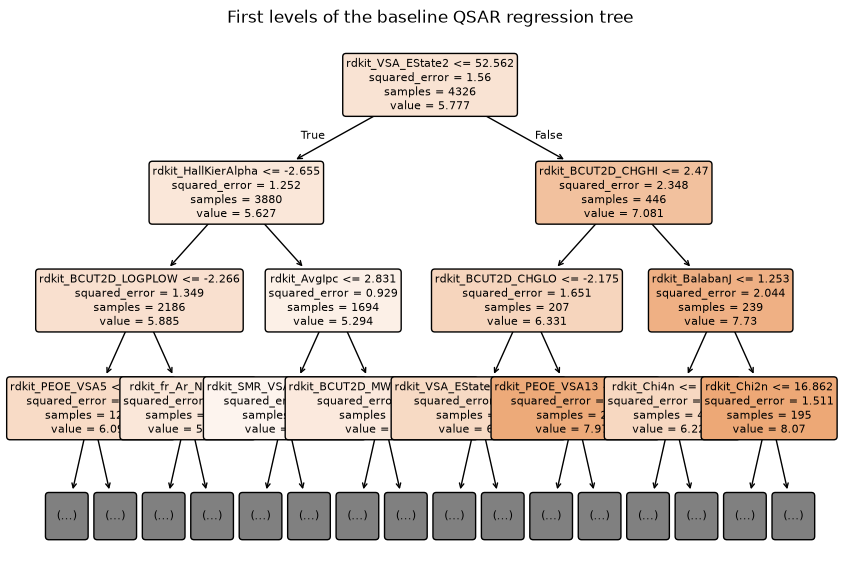

In [15]:
plt.figure(figsize=(10, 7))
plot_tree(
    tree.named_steps["model"],
    max_depth=3,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8,)
plt.title("First levels of the baseline QSAR regression tree")
plt.show()


### Questions

- Which descriptor is selected near the root?
- What target range is present in each child node?
- Is the split chemically interpretable, or is it only predictive in this sample?
- What information is lost when a continuous response is represented by terminal-node means?


# Part III — Tree complexity and pruning

Tree complexity controls the bias–variance trade-off. A very shallow tree may underfit; an unconstrained tree can memorize training compounds and assay noise.


## 8. Manual max_depth experiment

max_depth is the maximum number of split levels. Smaller values constrain the model; None allows growth until another stopping rule is reached.


In [16]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE)

depth_values = [1, 2, 3, 5, 8, 12, None]
depth_rows = []
for depth in depth_values:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("tree", DecisionTreeRegressor(
            max_depth=depth, min_samples_leaf=5, random_state=RANDOM_STATE
        )),
    ])
    model.fit(X_subtrain, y_subtrain)
    depth_rows.append({
        "max_depth": str(depth),
        "train_RMSE": np.sqrt(mean_squared_error(y_subtrain, model.predict(X_subtrain))),
        "validation_RMSE": np.sqrt(mean_squared_error(y_valid, model.predict(X_valid))),
        "train_R2": r2_score(y_subtrain, model.predict(X_subtrain)),
        "validation_R2": r2_score(y_valid, model.predict(X_valid)),
    })
depth_results = pd.DataFrame(depth_rows)
depth_results


,max_depth,train_RMSE,validation_RMSE,train_R2,validation_R2
0,1,1.165268,1.177305,0.128656,0.114515
1,2,1.108525,1.124241,0.211450,0.192539
2,3,1.066322,1.110608,0.270350,0.212003
3,5,0.982915,1.045935,0.380032,0.301104
4,8,0.773551,1.000714,0.616013,0.360230
5,12,0.525517,1.003162,0.822780,0.357097
6,None,0.464808,1.043942,0.861361,0.303765


## 9. Underfitting versus overfitting

Compare training and validation curves. A widening gap is evidence that the model is fitting patterns that do not transfer to held-out molecules.


In [17]:
depth_long = depth_results.melt(
    id_vars="max_depth",
    value_vars=["train_RMSE", "validation_RMSE"],
    var_name="split",
    value_name="RMSE",
)
depth_fig = px.line(
    depth_long, x="max_depth", y="RMSE", color="split", markers=True,
    title="Tree error versus max_depth",
    labels={"RMSE": "RMSE (lower is better)"},
)
depth_fig.show()

depth_r2_long = depth_results.melt(
    id_vars="max_depth",
    value_vars=["train_R2", "validation_R2"],
    var_name="split",
    value_name="R2",
)
depth_r2_fig = px.line(
    depth_r2_long, x="max_depth", y="R2", color="split", markers=True,
    title="Tree fit versus max_depth",
    labels={"R2": "R² (higher is better)"},
)
depth_r2_fig.show()


## 10. min_samples_leaf

min_samples_leaf is the minimum number of training observations allowed in a terminal leaf. Increasing it prevents very small, highly specialized leaves and usually smooths predictions.


In [18]:
leaf_values = [1, 2, 5, 10, 20, 50]
leaf_rows = []
for leaf_size in leaf_values:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("tree", DecisionTreeRegressor(
            max_depth=None, min_samples_leaf=leaf_size, random_state=RANDOM_STATE
        )),
    ])
    model.fit(X_subtrain, y_subtrain)
    leaf_rows.append({
        "min_samples_leaf": leaf_size,
        "train_RMSE": np.sqrt(mean_squared_error(y_subtrain, model.predict(X_subtrain))),
        "validation_RMSE": np.sqrt(mean_squared_error(y_valid, model.predict(X_valid))),
    })
leaf_results = pd.DataFrame(leaf_rows)
leaf_results


,min_samples_leaf,train_RMSE,validation_RMSE
0,1,0.084937,1.123765
1,2,0.232315,1.095796
2,5,0.464808,1.043942
3,10,0.621865,1.007243
4,20,0.762880,0.997697
5,50,0.914111,1.018158


In [19]:
leaf_long = leaf_results.melt(
    id_vars="min_samples_leaf",
    value_vars=["train_RMSE", "validation_RMSE"],
    var_name="split",
    value_name="RMSE",
)
leaf_fig = px.line(
    leaf_long, x="min_samples_leaf", y="RMSE", color="split",
    markers=True, log_x=True, title="Larger leaves regularize a tree",
)
leaf_fig.show()


## 11. Cost-complexity pruning

Cost-complexity pruning minimizes

$$
R_\alpha(T)=R(T)+\alpha |T|,
$$

where \(R(T)\) is the tree training impurity and \(|T|\) is the number of terminal leaves. Larger \(\alpha\) applies a stronger penalty to complex trees.


In [20]:
imputer_train = SimpleImputer(strategy="median")
X_train_imp = imputer_train.fit_transform(X_train)
X_test_imp = imputer_train.transform(X_test)

unpruned = DecisionTreeRegressor(random_state=RANDOM_STATE)
unpruned.fit(X_train_imp, y_train)
path = unpruned.cost_complexity_pruning_path(X_train_imp, y_train)
candidate_alphas = [0.0001, 0.01, 0.1, 1, 2]

pruning_rows = []
for alpha in candidate_alphas:
    model = DecisionTreeRegressor(
        ccp_alpha=float(alpha), min_samples_leaf=5, random_state=RANDOM_STATE
    )
    model.fit(X_train_imp, y_train)
    pruning_rows.append({
        "ccp_alpha": alpha,
        "leaves": model.get_n_leaves(),
        "validation_RMSE": np.sqrt(mean_squared_error(y_test, model.predict(X_test_imp))),
    })
pruning_results = pd.DataFrame(pruning_rows)
pruning_results.sort_values("validation_RMSE").head()


,ccp_alpha,leaves,validation_RMSE
0,0.0001,595,0.994676
1,0.0100,22,1.040734
2,0.1000,2,1.163525
3,1.0000,1,1.237378
4,2.0000,1,1.237378


In [21]:
pruning_fig = px.line(
    pruning_results, x="ccp_alpha", y="validation_RMSE",
    markers=True, hover_data=["leaves"], log_x=True,
    title="Cost-complexity pruning path",
    labels={"validation_RMSE": "RMSE"},
)
pruning_fig.show()


# Part IV — Bagging


## 12. Bootstrap aggregation

Bagging fits many models on bootstrap samples and averages their predictions:

$$
\hat{f}_{\mathrm{bag}}(x)=\frac{1}{B}\sum_{b=1}^{B}\hat{f}_b(x).
$$

The averaging mainly reduces variance. It does not make every base tree unbiased or biologically interpretable.


In [22]:
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=None, min_samples_leaf=5, random_state=RANDOM_STATE),
    n_estimators=150,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1)
    
bag_model.fit(X_train_imp, y_train)
bag_pred = bag_model.predict(X_test_imp)
show_metrics("Bagging", y_test, bag_pred)


Bagging
  RMSE: 0.767
  MAE:  0.574
  R²:   0.615


{'RMSE': np.float64(0.7673897059588308),
 'MAE': 0.5736045634871447,
 'R2': 0.6151590038057951}

## 13. Compare one tree with bagging


In [23]:
comparison = pd.DataFrame({
    "model": ["Decision tree", "Bagging"],
    "RMSE": [
        regression_metrics(y_test, tree_pred)["RMSE"],
        regression_metrics(y_test, bag_pred)["RMSE"],
    ],
    "MAE": [
        regression_metrics(y_test, tree_pred)["MAE"],
        regression_metrics(y_test, bag_pred)["MAE"],
    ],
    "R2": [
        regression_metrics(y_test, tree_pred)["R2"],
        regression_metrics(y_test, bag_pred)["R2"],
    ],
})


comparison


,model,RMSE,MAE,R2
0,Decision tree,1.043705,0.808893,0.288124
1,Bagging,0.767390,0.573605,0.615159


# Part V — Random Forest


## 14. Random Forest

Random Forest combines bootstrap aggregation with random feature subsampling at each split. The second source of randomness decorrelates trees, so averaging can reduce variance more effectively than averaging highly similar trees.


In [24]:
rf_model = RandomForestRegressor(
    n_estimators=250,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_imp, y_train)
rf_pred = rf_model.predict(X_test_imp)
show_metrics("Random Forest", y_test, rf_pred)


Random Forest
  RMSE: 0.732
  MAE:  0.553
  R²:   0.649


{'RMSE': np.float64(0.7324618330423915),
 'MAE': 0.5534731450587818,
 'R2': 0.6493939621066598}

## 15. Manual Random Forest hyperparameter exploration

- n_estimators: number of trees; more trees usually stabilize the estimate but increase runtime.
- max_features: number or fraction of descriptors considered at each split; smaller values increase tree diversity.
- max_depth: maximum tree depth; smaller values regularize.
- min_samples_leaf: minimum samples in a leaf; larger values smooth predictions.


In [25]:
manual_settings = [
    {"n_estimators": 100, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 250, "max_features": "sqrt", "min_samples_leaf": 2},
    {"n_estimators": 250, "max_features": 0.5, "min_samples_leaf": 2},
    {"n_estimators": 250, "max_features": 0.5, "min_samples_leaf": 8},
]
manual_rows = []
for settings in manual_settings:
    model = RandomForestRegressor(
        **settings, random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train_imp, y_train)
    manual_rows.append({**settings, **regression_metrics(y_test, model.predict(X_test_imp))})
manual_rf_results = pd.DataFrame(manual_rows).sort_values("RMSE")
manual_rf_results


,n_estimators,max_features,min_samples_leaf,RMSE,MAE,R2
0,100,sqrt,1,0.728708,0.552236,0.652978
2,250,0.5,2,0.730006,0.545005,0.651741
1,250,sqrt,2,0.732462,0.553473,0.649394
3,250,0.5,8,0.777828,0.586310,0.604619


## 16. Out-of-bag estimation

With bootstrap sampling, some observations are left out of each tree's training sample. The out-of-bag score uses those left-out predictions as an internal validation estimate. It is useful for diagnostics, but it does not replace a biologically appropriate external test set.


In [26]:
rf_oob = RandomForestRegressor(
    n_estimators=250,
    max_features="sqrt",
    min_samples_leaf=2,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1)
    
rf_oob.fit(X_train_imp, y_train)
print(f"OOB R²: {rf_oob.oob_score_:.3f}")
show_metrics("Random Forest with OOB", y_test, rf_oob.predict(X_test_imp))


OOB R²: 0.631
Random Forest with OOB
  RMSE: 0.732
  MAE:  0.553
  R²:   0.649


{'RMSE': np.float64(0.7324618330423914),
 'MAE': 0.5534731450587819,
 'R2': 0.6493939621066598}

# Part VI — Feature importance


## 17. Impurity-based importance

The forest reports how much each descriptor reduced split impurity, averaged over trees. Correlated descriptors can share or exchange importance, and descriptors with many possible split points can be favored.


In [ ]:
importance_plot_df = (
    impurity_importance.head(20)
    .sort_values()
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "descriptor"})
)
importance_fig = px.bar(
    importance_plot_df, x="importance", y="descriptor",
    orientation="h", title="Top Random Forest descriptors by impurity importance",
)
importance_fig.show()


NameError: name 'impurity_importance' is not defined

### QSAR interpretation

RDKit descriptors summarize properties such as molecular weight, lipophilicity, polar surface area, charge, rings, fragments, and topology. A predictive descriptor may be a proxy for several correlated chemical properties.




## 18. Permutation importance

Permutation importance measures how much a chosen score worsens when one feature is randomly shuffled in held-out data. It is often more useful for a generalization discussion than raw split importance, but correlated descriptors can still make the interpretation unstable.


In [ ]:
permutation = permutation_importance(
    rf_model,
    X_test_imp,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
permutation_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_score_change": permutation.importances_mean,
    "sd": permutation.importances_std,
}).sort_values("mean_score_change", ascending=False)
permutation_importance_df.head(20)


,feature,mean_score_change,sd
40,rdkit_HallKierAlpha,0.026596,0.003822
27,rdkit_BertzCT,0.017437,0.002136
93,rdkit_VSA_EState2,0.016381,0.001745
45,rdkit_PEOE_VSA1,0.013846,0.001568
72,rdkit_SlogP_VSA2,0.012695,0.001198
18,rdkit_BCUT2D_MWLOW,0.011308,0.001308
22,rdkit_BCUT2D_LOGPLOW,0.011300,0.000760
31,rdkit_Chi1,0.011240,0.000976
1,rdkit_MaxEStateIndex,0.009930,0.000959
57,rdkit_PEOE_VSA8,0.009299,0.001678


# Part VII — Gradient Boosting


## 20. Classical Gradient Boosting

Gradient boosting adds small trees sequentially, with each new tree correcting part of the current model's residual error:

$$
F_m(x)=F_{m-1}(x)+\eta h_m(x),
$$

where \(h_m\) is the next tree and \(\eta\) is the learning rate. Smaller \(\eta\) generally requires more trees and can improve regularization.


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=5,
    random_state=RANDOM_STATE)

    
gb_model.fit(X_train_imp, y_train)
gb_pred = gb_model.predict(X_test_imp)
show_metrics("Gradient Boosting", y_test, gb_pred)


Gradient Boosting
  RMSE: 0.917
  MAE:  0.718
  R²:   0.450


{'RMSE': np.float64(0.9173687657753936),
 'MAE': 0.7175457172724413,
 'R2': 0.45003216470322305}

## 21. Learning rate × number of trees

learning_rate scales each tree's contribution. n_estimators is the number of sequential trees. These parameters trade off model capacity, runtime, and regularization; they should be considered together.


In [ ]:
learning_rates = [0.02, 0.05, 0.10, 0.20]
boosting_trees = [50, 150, 300]
boosting_rows = []
for learning_rate in learning_rates:
    for n_estimators in boosting_trees:
        model = GradientBoostingRegressor(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_imp, y_train)
        boosting_rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            **regression_metrics(y_test, model.predict(X_test_imp)),
        })
boosting_results = pd.DataFrame(boosting_rows)
boosting_results.sort_values("RMSE").head(10)


,learning_rate,n_estimators,RMSE,MAE,R2
11,0.20,300,0.803629,0.609039,0.577953
10,0.20,150,0.840699,0.648838,0.538119
8,0.10,300,0.842584,0.650299,0.536045
7,0.10,150,0.902326,0.705159,0.467921
5,0.05,300,0.902422,0.704963,0.467807
9,0.20,50,0.930019,0.727574,0.434760
4,0.05,150,0.963784,0.755019,0.392972
2,0.02,300,0.980752,0.769927,0.371409
6,0.10,50,0.995033,0.781830,0.352971
1,0.02,150,1.032898,0.817878,0.302788


In [ ]:
boosting_plot_df = boosting_results.sort_values(["learning_rate", "n_estimators"]).copy()
boosting_fig = px.line(
    boosting_plot_df, x="n_estimators", y="RMSE", color="learning_rate",
    markers=True, hover_data=["MAE", "R2"],
    title="Learning rate and number of boosting trees",
    labels={"RMSE": "Test RMSE", "learning_rate": "learning_rate"},
)
boosting_fig.show()


# Part VIII — XGBoost


## 22. XGBoost

XGBoost is a regularized gradient-boosting implementation. Its commonly tuned parameters include n_estimators, learning_rate, max_depth, min_child_weight, subsample, and colsample_bytree.

The next cell is guarded because XGBoost is optional and is not needed for the core scikit-learn practical.


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train_imp, y_train)
show_metrics("XGBoost", y_test, xgb_model.predict(X_test_imp))


XGBoost
  RMSE: 0.755
  MAE:  0.574
  R²:   0.627


{'RMSE': np.float64(0.7550056803400792),
 'MAE': 0.5741040818043424,
 'R2': 0.6274797977058817}

### XGBoost parameters to explore

- n_estimators: number of boosting trees;
- learning_rate: contribution of each tree;
- max_depth: complexity of each tree;
- min_child_weight: minimum weight needed for a split;
- subsample: fraction of rows used for each tree;
- colsample_bytree: fraction of descriptors used for each tree;
- reg_alpha and reg_lambda: L1 and L2 regularization.

When comparing libraries, keep the split, metric, target, and preprocessing decisions fixed.


# Part IX — LightGBM


## 23. LightGBM

LightGBM is another gradient-boosting implementation designed for speed. num_leaves, max_depth, learning_rate, and n_estimators control the shape and amount of boosting. It can overfit small or highly correlated QSAR datasets if leaf complexity is not constrained.


In [ ]:

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=-1)

lgbm_model.fit(X_train_imp, y_train)
show_metrics("LightGBM", y_test, lgbm_model.predict(X_test_imp))


LightGBM
  RMSE: 0.700
  MAE:  0.519
  R²:   0.680


{'RMSE': np.float64(0.6997655227905775),
 'MAE': 0.5186138527093568,
 'R2': 0.6799966872864046}

## 24. Compare boosting libraries


In [ ]:
optional_rows = []
for name, model in [("XGBoost", xgb_model), ("LightGBM", lgbm_model)]:
    if model is not None:
        optional_rows.append({"model": name, **regression_metrics(y_test, model.predict(X_test_imp))})
pd.DataFrame(optional_rows)


,model,RMSE,MAE,R2
0,XGBoost,0.755006,0.574104,0.627480
1,LightGBM,0.699766,0.518614,0.679997


# Part X — Isolation Forest


## 25. Unsupervised anomaly and applicability-domain screening

Isolation Forest identifies points that are easy to isolate by random recursive splits. In a QSAR table, a flagged molecule may be chemically unusual, outside the model's applicability domain, a rare scaffold, affected by a descriptor calculation issue, or simply valid but unusual.

An anomaly flag is a prompt for inspection, not a decision to delete a compound.


In [ ]:
iso = IsolationForest(
    n_estimators=250, contamination="auto",
    random_state=RANDOM_STATE, n_jobs=-1)
    
X_all_imp = imputer_train.transform(X)
iso.fit(X_train_imp)
anomaly_df = molecule_df[[MOLECULE_ID, SMILES_COLUMN, TARGET, "n_measurements"]].copy()
anomaly_df["IF_label"] = iso.predict(X_all_imp)
anomaly_df["IF_score"] = iso.decision_function(X_all_imp)


anomaly_pubchem = fetch_pubchem_metadata(anomaly_df[SMILES_COLUMN], max_new=None)
anomaly_df = (
    anomaly_df.drop(
        columns=["pubchem_cid", "pubchem_iupac_name", "pubchem_status"],
        errors="ignore",
    )
    .merge(anomaly_pubchem, left_on=SMILES_COLUMN, right_on="smiles", how="left")
    .drop(columns=["smiles"])
)


## 26. Inspect the most isolated molecules


In [ ]:
anomaly_df.sort_values("IF_score").head(15).style.format({"pchembl_value": "{:.2f}", "IF_score": "{:.3f}"})


,molecule_chembl_id,canonical_smiles,pchembl_value,n_measurements,IF_label,IF_score,pubchem_cid,pubchem_iupac_name,pubchem_status
2071,CHEMBL267237,CC[C@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CC(N)CSC1CC(=O)N(CCC(=O)O[C@@H](C(=O)O[C@@H]2C(C)=CC3[C@@H](OC(C)=O)C(=O)[C@@]4(C)[C@H]([C@H](OC(=O)c5ccccc5)[C@@]2(O)C3(C)C)[C@]2(OC(C)=O)CO[C@@H]2C[C@@H]4O)[C@@H](NC(=O)c2ccccc2)c2ccccc2)C1=O)[C@@H](C)CC)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)O,6.57,1,-1,-0.234,44410915.000000,"(2S)-6-amino-2-[[(2S)-6-amino-2-[[(2S)-2-[[(2S)-6-amino-2-[[(2S)-2-[[(2S)-2-[[(2S)-2-[[(2S)-4-amino-2-[[(2S)-5-amino-2-[[(2S)-2-[[(2S)-2-[[(2S,3S)-2-[[(2S)-6-amino-2-[[(2S,3S)-2-[[(2S)-5-amino-2-[[(2S)-2-[[3-amino-4-[1-[3-[(1S,2R)-1-benzamido-3-[[(1S,2S,3R,4S,7R,9S,10S,12R,16R)-4,12-diacetyloxy-2-benzoyloxy-1,9-dihydroxy-10,15,17,17-tetramethyl-11-oxo-6-oxatetracyclo[11.3.1.03,10.04,7]heptadec-14-en-16-yl]oxy]-3-oxo-1-phenylpropan-2-yl]oxy-3-oxopropyl]-2,5-dioxopyrrolidin-3-yl]sulfanylbutanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-5-oxopentanoyl]amino]-3-methylpentanoyl]amino]hexanoyl]amino]-3-methylpentanoyl]amino]-3-(1H-indol-3-yl)propanoyl]amino]-3-phenylpropanoyl]amino]-5-oxopentanoyl]amino]-4-oxobutanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-4-methylsulfanylbutanoyl]amino]hexanoyl]amino]-3-(1H-indol-3-yl)propanoyl]amino]hexanoyl]amino]hexanoic acid",matched
4060,CHEMBL437106,CC[C@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CC(N)CSC1CC(=O)N(CC(=O)O[C@H]2C[C@H]3OC[C@@]3(OC(C)=O)[C@H]3[C@H](OC(=O)c4ccccc4)[C@]4(O)[C@H](OC(=O)[C@H](O)[C@@H](NC(=O)c5ccccc5)c5ccccc5)C(C)=CC([C@@H](OC(C)=O)C(=O)[C@]23C)C4(C)C)C1=O)[C@@H](C)CC)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)O,5.00,1,-1,-0.233,44410918.000000,"(2S)-6-amino-2-[[(2S)-6-amino-2-[[(2S)-2-[[(2S)-6-amino-2-[[(2S)-2-[[(2S)-2-[[(2S)-2-[[(2S)-4-amino-2-[[(2S)-5-amino-2-[[(2S)-2-[[(2S)-2-[[(2S,3S)-2-[[(2S)-6-amino-2-[[(2S,3S)-2-[[(2S)-5-amino-2-[[(2S)-2-[[3-amino-4-[1-[2-[[(1S,2S,3R,4S,7R,9S,10S,12R,16R)-4,12-diacetyloxy-16-[(2R,3S)-3-benzamido-2-hydroxy-3-phenylpropanoyl]oxy-2-benzoyloxy-1-hydroxy-10,15,17,17-tetramethyl-11-oxo-6-oxatetracyclo[11.3.1.03,10.04,7]heptadec-14-en-9-yl]oxy]-2-oxoethyl]-2,5-dioxopyrrolidin-3-yl]sulfanylbutanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-5-oxopentanoyl]amino]-3-methylpentanoyl]amino]hexanoyl]amino]-3-methylpentanoyl]amino]-3-(1H-indol-3-yl)propanoyl]amino]-3-phenylpropanoyl]amino]-5-oxopentanoyl]amino]-4-oxobutanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-5-(diaminomethylideneamino)pentanoyl]amino]-4-methylsulfanylbutanoyl]amino]hexanoyl]amino]-3-(1H-indol-3-yl)propanoyl]amino]hexanoyl]amino]hexanoic acid",matched
3870,CHEMBL415401,CC[C@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CC(N)CSC1CC(=O)N(CCC(=O)O[C@@H](C(=O)O[C@@H]2C(C)=CC3[C@@H](OC(C)=O)C(=O)[C@@]4(C)[C@H]([C@H](OC(=O)c5ccccc5)[C@@]2(O)C3(C)C)[C@]2(OC(C)=O)CO[C@@H]2C[C@@H]4O)[C@@H](NC(=O)c2ccccc2)c2ccccc2)C1=O)[C@@H](C)CC)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(N)=O,6.70,2,-1,-0.228,44410916.000000,"[(1S,2S,3R,4S,7R,9S,10S,12R,16R)-4,12-diacetyloxy-16-[(2R,3S)-2-[3-[3-[2-amino-4-[[(2S)-1-[[(2S)-5-amino-1-[[(2S,3S)-1-[[(2S)-6-amino-1-[[(2S,3S)-1-[[

### Discussion

Isolation Forest is unsupervised: it does not use pchembl_value. A low score means unusual descriptor-space geometry, not necessarily a bad experiment or a biologically false target.


# Part XI — Cross-validation


## 27. Choose the correct CV design

Aggregation gives one row per molecule, so ordinary shuffled KFold is technically valid for this modelling table. It estimates performance for random molecule splits, not necessarily for new chemical scaffolds.

If raw assay rows were used, all measurements of the same molecule would need to stay in the same fold. For scaffold generalization, define a scaffold/group label and use GroupKFold or a scaffold-specific split.


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200, max_features="sqrt", min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1)),
])


## 28. Baseline cross-validation

The negative RMSE convention is used by scikit-learn scorers: larger is better, so we multiply by -1 before reporting RMSE.


In [ ]:
cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1)
print("Fold RMSE:", np.round(-cv_scores, 3))
print(f"Mean ± SD RMSE: {-cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Fold RMSE: [0.757 0.796 0.81  0.748 0.805]
Mean ± SD RMSE: 0.783 ± 0.026


# Part XII — Hyperparameter optimization


## 29. Grid Search

Grid search evaluates every combination in a predefined Cartesian grid. It is transparent, but the number of fits grows quickly as more values are added.


In [ ]:
param_grid = {
    "model__n_estimators": [100, 250],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [2, 8],
    "model__max_features": ["sqrt", 0.5],
}
grid = GridSearchCV(
    rf_pipeline, param_grid=param_grid, cv=3,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
    return_train_score=True,
)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ate=100626))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10], 'model__max_features': ['sqrt', 0.5], 'model__min_samples_leaf': [2, 8], 'model__n_estimators': [100, 250]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_

## 30. Grid results


In [ ]:
print("Best parameters:", grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:.3f}")
grid_results = pd.DataFrame(grid.cv_results_)
grid_results.sort_values("rank_test_score")[["params", "mean_test_score", "std_test_score", "mean_train_score"]].head(10)


Best parameters: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__n_estimators': 250}
Best CV RMSE: 0.783


,params,mean_test_score,std_test_score,mean_train_score
5,"{'model__max_depth': None, 'model__max_feature...",-0.782622,0.006543,-0.345588
4,"{'model__max_depth': None, 'model__max_feature...",-0.784010,0.006472,-0.347731
1,"{'model__max_depth': None, 'model__max_feature...",-0.792580,0.009136,-0.382878
0,"{'model__max_depth': None, 'model__max_feature...",-0.794866,0.008888,-0.385100
13,"{'model__max_depth': 10, 'model__max_features'...",-0.829298,0.004954,-0.554445
7,"{'model__max_depth': None, 'model__max_feature...",-0.830864,0.009858,-0.579811
12,"{'model__max_depth': 10, 'model__max_features'...",-0.831783,0.005338,-0.556378
6,"{'model__max_depth': None, 'model__max_feature...",-0.832884,0.010248,-0.580681
9,"{'model__max_depth': 10, 'model__max_features'...",-0.848861,0.008873,-0.606199
8,"{'model__max_depth': 10, 'model__max_features'...",-0.849119,0.009561,-0.607120


## 31. Random Search

Random search samples configurations from distributions. It can explore a large hyperparameter space more efficiently than a small grid when only some parameters strongly affect performance.


In [ ]:
from scipy.stats import randint

param_distributions = {
    "model__n_estimators": randint(100, 401),
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_leaf": randint(1, 16),
    "model__max_features": ["sqrt", 0.5, 0.8]}
    
random_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=param_distributions,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True,
)
random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print(f"Best CV RMSE: {-random_search.best_score_:.3f}")


Best parameters: {'model__max_depth': 15, 'model__max_features': 0.8, 'model__min_samples_leaf': 6, 'model__n_estimators': 374}
Best CV RMSE: 0.815


## 32. Compare Grid Search with Random Search


In [ ]:
search_comparison = pd.DataFrame([
    {"method": "Grid search", "trials": len(grid.cv_results_["params"]),
     "best_cv_RMSE": -grid.best_score_},
    {"method": "Random search", "trials": len(random_search.cv_results_["params"]),
     "best_cv_RMSE": -random_search.best_score_},
])
search_comparison


,method,trials,best_cv_RMSE
0,Grid search,16,0.782622
1,Random search,10,0.814959


# Part XIII — Optional Bayesian optimization


## 33. Optuna

Bayesian optimization chooses the next trial using information from previous trials. It can be useful when model fits are expensive, but it still must optimize cross-validation performance on the training set only.


In [ ]:
import optuna

def objective(trial):
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=trial.suggest_int("n_estimators", 100, 350),
                max_depth=trial.suggest_int("max_depth", 3, 15),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 15),
                max_features=trial.suggest_categorical("max_features", ["sqrt", 0.5, 0.8]),
                random_state=RANDOM_STATE, n_jobs=-1,
            )),
        ])
        scores = cross_val_score(
            model, X_train, y_train, cv=3,
            scoring="neg_root_mean_squared_error", n_jobs=-1,
        )
        return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15, show_progress_bar=False)
print("Best Optuna RMSE:", study.best_value)
print("Best Optuna parameters:", study.best_params)


[I 2026-10-03 16:25:36,243] A new study created in memory with name: no-name-c121e5af-b2e6-4573-a63a-7f0182152829
[I 2026-10-03 16:25:39,673] Trial 0 finished with value: 0.8594246122329423 and parameters: {'n_estimators': 175, 'max_depth': 10, 'min_samples_leaf': 9, 'max_features': 0.5}. Best is trial 0 with value: 0.8594246122329423.
[I 2026-10-03 16:25:46,350] Trial 1 finished with value: 0.8474888707384478 and parameters: {'n_estimators': 237, 'max_depth': 11, 'min_samples_leaf': 9, 'max_features': 0.8}. Best is trial 1 with value: 0.8474888707384478.
[I 2026-10-03 16:25:49,460] Trial 2 finished with value: 0.8728866065513844 and parameters: {'n_estimators': 182, 'max_depth': 9, 'min_samples_leaf': 9, 'max_features': 0.5}. Best is trial 1 with value: 0.8474888707384478.
[I 2026-10-03 16:25:50,214] Trial 3 finished with value: 1.0478273617797818 and parameters: {'n_estimators': 235, 'max_depth': 4, 'min_samples_leaf': 11, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.847488

Best Optuna RMSE: 0.7943039629584184
Best Optuna parameters: {'n_estimators': 340, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 0.8}


## 34. Inspect Bayesian search


In [ ]:

pd.DataFrame([study.best_params])


,n_estimators,max_depth,min_samples_leaf,max_features
0,340,14,2,0.8


## 35. Visualize the search process

The search result is more informative when we inspect all tried configurations rather than only the best row. The interactive Plotly figures show validation RMSE for every grid/random trial and the trajectory of Bayesian trials. Lower RMSE is better; the final test set is not used here.


In [ ]:
search_rows = []
for method, results in [
    ("Grid search", grid_results),
    ("Random search", pd.DataFrame(random_search.cv_results_)),
]:
    for trial_number, row in results.reset_index(drop=True).iterrows():
        search_rows.append({
            "method": method,
            "trial": trial_number + 1,
            "cv_RMSE": -row["mean_test_score"],
            "parameters": str(row["params"]),
        })
for trial_number, trial in enumerate(study.trials, start=1):
    if trial.value is not None:
        search_rows.append({
            "method": "Bayesian search",
            "trial": trial_number,
            "cv_RMSE": trial.value,
            "parameters": str(trial.params),
        })
search_trials = pd.DataFrame(search_rows)
search_trial_fig = px.scatter(
    search_trials, x="trial", y="cv_RMSE", color="method",
    hover_data=["parameters"],
    title="Validation error across hyperparameter trials",
    labels={"cv_RMSE": "CV RMSE (lower is better)"},
)
search_trial_fig.show()

best_search_summary = pd.DataFrame([
    {"method": "Grid search", "best_cv_RMSE": -grid.best_score_},
    {"method": "Random search", "best_cv_RMSE": -random_search.best_score_},
    {"method": "Bayesian search", "best_cv_RMSE": study.best_value},
])
best_search_fig = px.bar(
    best_search_summary, x="method", y="best_cv_RMSE", color="method",
    title="Best cross-validation RMSE by search strategy",
)
best_search_fig.show()


# Part XIV — Final model comparison


## 36. Compare tree-based models

Use the same molecule-level split and the same evaluation metrics. The comparison is about both performance and the assumptions and costs of each model.


In [ ]:
comparison_models = {
    "Decision tree": tree,
    "Bagging": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", BaggingRegressor(
            estimator=DecisionTreeRegressor(min_samples_leaf=5, random_state=RANDOM_STATE),
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "Random Forest": rf_pipeline,
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=250, learning_rate=0.05, max_depth=2,
            min_samples_leaf=5, random_state=RANDOM_STATE,
        )),
    ]),
}

final_rows = []
for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    final_rows.append({"model": name, **regression_metrics(y_test, model.predict(X_test))})
if xgb_model is not None:
    final_rows.append({"model": "XGBoost", **regression_metrics(y_test, xgb_model.predict(X_test_imp))})
if lgbm_model is not None:
    final_rows.append({"model": "LightGBM", **regression_metrics(y_test, lgbm_model.predict(X_test_imp))})

final_comparison = pd.DataFrame(final_rows).sort_values("RMSE")
final_comparison


,model,RMSE,MAE,R2
5,LightGBM,0.699766,0.518614,0.679997
2,Random Forest,0.734690,0.555039,0.647258
4,XGBoost,0.755006,0.574104,0.627480
1,Bagging,0.767390,0.573605,0.615159
3,Gradient Boosting,0.917369,0.717546,0.450032
0,Decision tree,1.043705,0.808893,0.288124


### Questions

- Does the most complex model perform best on held-out molecules?
- Which model is most stable across CV folds?
- Which model is easiest to inspect and explain?
- Does a good random-split score guarantee performance on a new chemical scaffold?
- Which model would you choose for this dataset, and what evidence supports that choice?


# Part XV — Bonus: Stacking


## 37. Stacking

Stacking trains several base models and uses their out-of-fold predictions as features for a second-level model:

$$
(p_{\mathrm{tree}},p_{\mathrm{RF}},p_{\mathrm{GB}})
\rightarrow
\text{meta-model}
\rightarrow
\hat{y}.
$$

The out-of-fold step is essential: if the meta-model sees predictions made on the same observations used to fit a base model, it can learn from overfitted predictions.


In [ ]:
stack_estimators = [
    ("tree", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(
            max_depth=6, min_samples_leaf=8, random_state=RANDOM_STATE
        )),
    ])),
    ("rf", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=150, max_features="sqrt", min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])),
    ("gb", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=2,
            min_samples_leaf=5, random_state=RANDOM_STATE,
        )),
    ])),
    ("lgb", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=-1))]))]
        
stack = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1,
)
stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)
show_metrics("Stacking ensemble", y_test, stack_pred)


Stacking ensemble
  RMSE: 0.685
  MAE:  0.503
  R²:   0.693


{'RMSE': np.float64(0.685420041378489),
 'MAE': 0.5029768062841389,
 'R2': 0.6929825998954613}

## 38. Compare error distributions before and after stacking

For every model, define the signed prediction error as \(e_i=y_i-\hat{y}_i\). A useful ensemble should reduce typical error without creating a new systematic bias. The interactive violin plots show the full held-out error distribution, with a box plot overlaid for the median and interquartile range.


In [ ]:
stack_error_rows = []
for name, estimator in stack.named_estimators_.items():
    model_prediction = estimator.predict(X_test)
    stack_error_rows.extend({
        "model": name,
        "error": actual - predicted,
        "absolute_error": abs(actual - predicted),
    } for actual, predicted in zip(y_test, model_prediction))
stack_error_rows.extend({
    "model": "stacked",
    "error": actual - predicted,
    "absolute_error": abs(actual - predicted),
} for actual, predicted in zip(y_test, stack_pred))

stack_errors = pd.DataFrame(stack_error_rows)
error_summary = (
    stack_errors.groupby("model")["error"]
    .agg(mean_error="mean", median_error="median", sd="std")
    .assign(MAE=stack_errors.groupby("model")["absolute_error"].mean())
    .sort_values("MAE")
)

error_fig = px.violin(
    stack_errors, x="model", y="error", color="model",
    box=True, points=False, hover_data=["absolute_error"],
    title="Held-out prediction-error distributions",
    labels={"error": "Signed error: actual − predicted"},
)
error_fig.add_hline(y=0, line_dash="dash", line_color="black")
error_fig.show()
print(error_summary)

         mean_error  median_error        sd       MAE
model                                                
stacked    0.010682      0.006404  0.685654  0.502977
lgb       -0.007878     -0.030514  0.700045  0.518614
rf        -0.020624     -0.082795  0.734341  0.554360
gb        -0.009249     -0.116088  0.939286  0.734977
tree      -0.010370     -0.091588  1.033443  0.791918


### Discussion

Stacking is useful when base models make complementary errors. It is not guaranteed to improve performance, and it increases training cost and interpretive complexity. Compare it with the strongest single model using cross-validation, not only one test split.


# Part XVI — hometask


## 39. Similiar dataset - different endpoiny

>week5\chembl_antimicrobial_rdkit_descriptors_outcomes.tar.gz
